In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [17]:
# class Particle:
#     def __init__(self, pos, vel, mass, species):
#         # pos, vel are each 3d arrays giving the xyz components
#         # leave acc empty for now and update later,
#         # bc this is based on all other particles?
#         self.pos = pos
#         self.vel = vel
#         self.mass = mass
#         self.acc = np.zeros(3)
#         self.species = species

class System:
    def __init__(self, positions, velocities, masses, is_star,
                 G=1.0, softening=0.01, drag_coeff=0.0, drag_radius=0.0):
        self.pos = np.asarray(positions, dtype=float)   # (N, D)
        self.vel = np.asarray(velocities, dtype=float)  # (N, D)
        self.mass = np.asarray(masses, dtype=float)     # (N,)
        self.is_star = np.asarray(is_star, dtype=bool)  # (N,)

        self.G = G
        self.eps2 = softening**2
        self.drag_coeff = drag_coeff
        self.drag_radius = drag_radius

        self.acc = self.compute_accelerations()  # initial acceleration for leapfrog

    def compute_accelerations(self):
        r = self.pos[None, :, :] - self.pos[:, None, :]      # r[i,j] = pos_j - pos_i, shape (N,N,D)
        dist2 = np.sum(r**2, axis=-1) + self.eps2             # (N,N)
        inv_dist3 = dist2 ** -1.5
        np.fill_diagonal(inv_dist3, 0.0)                      # exclude self-interaction

        # gravity: acc_i = G * sum_j m_j * r_ij / dist_ij^3
        acc = self.G * np.sum(self.mass[None, :, None] * r * inv_dist3[:, :, None], axis=1)

        if self.drag_coeff > 0:
            star_pair = self.is_star[:, None] & self.is_star[None, :]
            dist = np.sqrt(dist2)
            close = (dist < self.drag_radius) & star_pair
            np.fill_diagonal(close, False)

            vel_diff = self.vel[None, :, :] - self.vel[:, None, :]   # vel_diff[i,j] = vel_j - vel_i
            drag_force = self.drag_coeff * vel_diff * close[:, :, None]  # force ON i from j
            acc += drag_force.sum(axis=1) / self.mass[:, None]

        return acc

    def step(self, dt):
        self.vel += 0.5 * self.acc * dt   # kick
        self.pos += self.vel * dt         # drift
        self.acc = self.compute_accelerations()
        self.vel += 0.5 * self.acc * dt   # kick


    

In [70]:
dm_mass = 10
star_mass = 1

N_dm = 50
N_star = 50

def make_cluster(n, center, bulk_vel, radius, mass, vel_dispersion=None, rng=None):
    rng = rng or np.random.default_rng()
    D = len(center)

    # positions: uniform within a sphere/disk of `radius` around `center`
    directions = rng.normal(size=(n, D))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = radius * rng.random(n) ** (1 / D)   # uniform-in-volume, not just uniform-in-radius
    positions = np.array(center) + directions * radii[:, None]

    # velocities: common bulk motion + small internal random dispersion
    if vel_dispersion is None:
        vel_dispersion = np.sqrt(mass / radius)   # rough virial estimate (G=1)
    velocities = np.array(bulk_vel) + rng.normal(scale=vel_dispersion, size=(n, D))

    masses = np.ones(n) * mass
    return positions, velocities, masses


rng = np.random.default_rng(42)

pos1, vel1, mass1 = make_cluster(1, center=[-10,  0, 0], bulk_vel=[ 1, 0, 0], radius=2, mass=star_mass, rng=rng)
pos2, vel2, mass2 = make_cluster(1, center=[ 10, -1, 0], bulk_vel=[-1, 0, 0], radius=2, mass=star_mass, rng=rng)

positions  = np.vstack([pos1, pos2])
# velocities = np.vstack([vel1, vel2])
velocities = np.vstack([[ 1, 0, 0], [ -1, 0, 0]])
masses     = np.concatenate([mass1, mass2])
is_star    = np.ones(len(masses), dtype=bool)

sys = System(positions, velocities, masses, is_star, G=1.0, softening=0.3)



# sys = System(
#     positions=np.vstack([galaxy1_pos, galaxy2_pos, halo1_pos, halo2_pos]),
#     velocities=np.vstack([galaxy1_vel, galaxy2_vel, halo1_vel, halo2_vel]),
#     masses=np.concatenate([galaxy1_mass, galaxy2_mass, halo1_mass, halo2_mass]),
#     is_star=np.concatenate([np.ones(len(galaxy1_mass)+len(galaxy2_mass), bool),
#                              np.zeros(len(halo1_mass)+len(halo2_mass), bool)]),
#     G=1.0, softening=0.05, drag_coeff=0.1, drag_radius=0.2,
# )


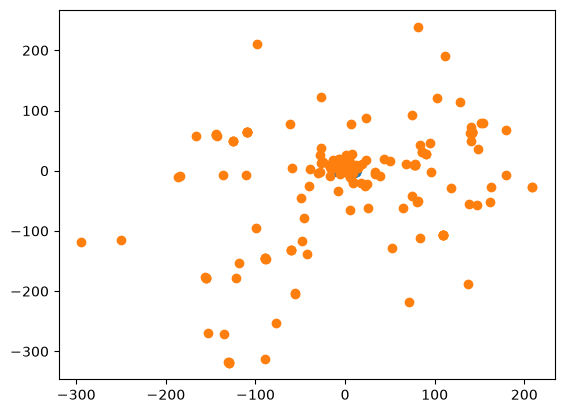

In [37]:
plt.scatter(sys.pos[:,0], sys.pos[:,1])

nsteps = 1000
dt = 0.02
for i in range(nsteps):
    sys.step(dt)

plt.scatter(sys.pos[:,0], sys.pos[:,1])

In [30]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [71]:
dt = 0.03
steps_per_frame = 2   # advance physics a few steps per rendered frame
n_frames = 400

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('black')
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])

star_scatter = ax.scatter([], [], s=3, c='white')
dm_scatter   = ax.scatter([], [], s=1, c='gray', alpha=0.3)

def update(frame):
    for _ in range(steps_per_frame):
        sys.step(dt)
    star_scatter.set_offsets(sys.pos[sys.is_star])
    dm_scatter.set_offsets(sys.pos[~sys.is_star])
    return star_scatter, dm_scatter

ani = FuncAnimation(fig, update, frames=n_frames, interval=30, blit=True)
plt.close(fig)          # prevents a duplicate static plot from also showing
HTML(ani.to_jshtml())    # renders as an interactive player with play/pause/scrub
